# RiskModels.net: From Data to Decision in 5 Minutes

This demo shows how the RiskModels platform can quickly analyze risk and build optimized portfolios using our factor risk model.


---

### Universe Selection

In this step, I’ll load our dataset from the API — with a local fallback just in case.  
We then select the **top 25 U.S. stocks by market cap** as our demo universe.  
This keeps things simple, but the same approach works on the full **1,000-stock Professional dataset**.

---

In [1]:
import xarray as xr
import pandas as pd
import numpy as np
import sys
import os
import warnings
import logging

optimizer_logger = logging.getLogger('utils.PortfolioOptimizer')
optimizer_logger.setLevel(logging.INFO)

if not optimizer_logger.handlers:
    handler = logging.StreamHandler()
    formatter = logging.Formatter('%(asctime)s [%(levelname)s] %(message)s', datefmt='%H:%M:%S')
    handler.setFormatter(formatter)
    optimizer_logger.addHandler(handler)

# Add project root to path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.append(project_root)

from utils.PortfolioOptimizer import ClassicOptimizer, FactorModelOptimizer
from utils.utils_plotting import plot_optimizer_performance, create_optimizer_summary_table
from utils.utils_simulate import generate_train_predict_calender
import plotly.express as px
from IPython.display import display
from sklearn.pipeline import Pipeline
from tqdm.notebook import tqdm
%matplotlib inline

# Load the dataset from API with local fallback
try:
    # Attempt to load from Google Cloud Storage
    zarr_path = 'gs://rm_api_data/Professional'
    ds = xr.open_zarr(zarr_path, consolidated=False)
    print(f"Successfully loaded data from {zarr_path} with {len(ds.ticker)} stocks.")
except Exception as e:
    print(f"Failed to load from API: {e}")
    print("Falling back to local dataset...")
    ds = xr.load_dataset('../data/eagle_alpha_demo.nc')
    print(f"Successfully loaded local data with {len(ds.ticker)} stocks.")

ds = xr.load_dataset('../data/eagle_alpha_demo.nc')
# Select the top 25 stocks by the most recent market cap
latest_date = ds.date.values.max()
market_caps = ds['mktcap'].sel(date=latest_date).to_pandas()
top_25_tickers = market_caps.sort_values(ascending=False).head(25).index.tolist()
demo_ds = ds.sel(ticker=top_25_tickers)

demo_ds = demo_ds.dropna(dim='date', how='any')
print("\nCleaned data: removed dates with missing values.")
print(f"New date range: {pd.to_datetime(demo_ds.date.values[0]).strftime('%Y-%m-%d')} "
      f"to {pd.to_datetime(demo_ds.date.values[-1]).strftime('%Y-%m-%d')}")

print("\nSelected Universe (Top 25 by Market Cap):")
print(demo_ds.ticker.values)



Cleaned data: removed dates with missing values.
New date range: 2023-01-18 to 2025-09-12

Selected Universe (Top 25 by Market Cap):
['NVDA' 'MSFT' 'AAPL' 'AMZN' 'META' 'AVGO' 'GOOG' 'GOOGL' 'TSLA' 'JPM'
 'WMT' 'ORCL' 'LLY' 'BRK.B' 'BRK.A' 'V' 'MA' 'NFLX' 'XOM' 'COST' 'JNJ'
 'HD' 'BAC' 'PLTR' 'PG']


---

### 2. Factor Exposure Matrix

Next, we’ll visualize the portfolio’s risk drivers.  
Our factor model decomposes risk into three clear components:  
- **Market**  
- **Sector**  
- **Residual (stock-specific)**  

*This step shows how transparent the model is. Instead of a black box, you can see exactly where your exposures lie.  
The heatmap makes it easy to spot concentrations — for example, if the portfolio is leaning too heavily on one sector or the market factor.*

*By breaking risk into market, sector, and stock-specific components, investors can pinpoint hidden exposures that drive volatility.*  

---


In [2]:
demo_ds

<xarray.Dataset> Size: 2MB
Dimensions:                (date: 666, ticker: 25)
Coordinates:
  * date                   (date) datetime64[ns] 5kB 2023-01-18 ... 2025-09-12
  * ticker                 (ticker) object 200B 'NVDA' 'MSFT' ... 'PLTR' 'PG'
Data variables: (12/23)
    bw_sector_name         (date, ticker) object 133kB 'Information_Technolog...
    sector_etf             (date, ticker) object 133kB 'XLK' 'XLK' ... 'XLP'
    bw_sector_code         (date, ticker) float32 67kB 45.0 45.0 ... 45.0 30.0
    close                  (date, ticker) float32 67kB 173.8 235.8 ... 157.9
    cross_term_risk_pct    (date, ticker) float32 67kB 0.006511 ... 0.004366
    etf_mkt_beta           (date, ticker) float32 67kB 1.289 1.289 ... 0.3057
    ...                     ...
    sector_beta            (date, ticker) float32 67kB 2.181 0.9207 ... 1.096
    sector_contr_variance  (date, ticker) float32 67kB 1.915 0.3261 ... 0.7785
    sector_factor_beta     (date, ticker) float32 67kB 2.181 0.9207 ... 1.096
    sector_factor_return   (date, ticker) float32 67kB 0.7452 0.7452 ... -0.3248
    sector_hedge_wt        (date, ticker) float32 67kB -2.181 -0.9207 ... -1.096
    sector_risk_pct        (date, ticker) float32 67kB 0.1107 0.07355 ... 0.6049

In [3]:
FactorModelOptimizer?

Init signature:
FactorModelOptimizer(
    method_f='ewma1',
    method_F='ewma1',
    halflife=30,
    returns_var='return',
    rm='MV',
    obj='Sharpe',
    rf=0.0,
    l=0.0,
    sht=True,
    budget=1.0,
    budgetsht=0.2,
    uppersht=0.2,
    upperlng=1.0,
    user_input_mu=None,
    user_input_cov=None,
    use_custom_inputs=False,
    user_input_f=None,
    user_input_F=None,
    use_custom_factor_inputs=False,
)
Docstring:     
Scikit-learn compatible Factor Model optimizer.

Parameters
----------
method_f : str, default='ewma1'
    Method for factor return estimation
method_F : str, default='ewma1'
    Method for factor covariance estimation
halflife : int, default=30
    EWMA halflife in days
returns_var : str, default='return'
    Column name for returns
rm : str, default='MV'
    Risk measure
obj : str, default='Sharpe'
    Optimization objective
rf : float, default=0.0
    Risk-free rate
l : float, default=0.0
    Risk aversion parameter
sht : bool, default=True
    Allo

In [4]:
factor_analyzer.F_

NameError: name 'factor_analyzer' is not defined

In [5]:
# 1. Instantiate the FactorModelOptimizer
# We fit it here just to get the B_ matrix for visualization.
# In a real workflow, you would fit on every rebalancing date
factor_analyzer = FactorModelOptimizer(method_F='hist', method_f='ewma2')
factor_analyzer.fit(demo_ds)

# 2. Retrieve the Factor Exposure Matrix (B)
# This matrix is calculated by the optimizer during the .fit() process.
exposures_df = factor_analyzer.B_

# 3. Create a clean table of the exposures
if exposures_df is not None:
    styled_exposures = exposures_df.style.background_gradient(
        cmap='RdBu_r',  # Red-Blue diverging palette
        axis=None,     # Apply to all cells
        vmin=-1.5,     # Set a min value for the color scale
        vmax=1.5       # Set a max value for the color scale
    ).format(
        '{:.2f}'      # Format all numbers to 2 decimal places
    ).set_caption(
        'Factor Exposure Matrix (Beta)'
    ).set_table_styles(
    [
        {
            "selector": "caption",
            "props": [("caption-side", "top"),
                      ("font-size", "14pt"),
                      ("font-weight", "bold"),
                      ("text-align", "center")]
        }
    ]
)

    display(styled_exposures)
else:
    print("Factor exposure matrix (B_) was not generated.")

11:03:31 [INFO] Constructing factor exposure matrix B and residual variance D...
11:03:31 [INFO] Factor exposure matrix B shape: (25, 7)
11:03:31 [INFO] B and D matrices constructed.
11:03:31 [INFO] Computing factor model mu and sigma...
11:03:31 [INFO] Expected factor returns method: ewma2
11:03:31 [INFO] Factor covariance method: hist
11:03:31 [INFO] Asset covariance matrix Σ shape: (25, 25)


,Market,Consumer_Discretionary,Consumer_Staples,Energy,Financials,Health_Care,Information_Technology
ticker,,,,,,,
AAPL,1.19,-0.00,-0.00,-0.00,-0.00,-0.00,-0.13
AMZN,1.26,0.86,0.00,0.00,0.00,0.00,0.00
AVGO,1.78,0.00,0.00,0.00,0.00,0.00,2.30
BAC,0.98,0.00,0.00,0.00,1.09,0.00,0.00
BRK.A,0.52,0.00,0.00,0.00,0.89,0.00,0.00
BRK.B,0.55,0.00,0.00,0.00,1.01,0.00,0.00
COST,0.45,0.14,0.00,0.00,0.00,0.00,0.00
GOOG,1.00,0.00,0.00,0.00,0.00,0.00,0.37
GOOGL,0.99,0.00,0.00,0.00,0.00,0.00,0.39


### 3. Strategy & Optimization

Now, we'll run a rolling backtest to compare two strategies:

1.  **Factor Model Portfolio:** A Sharpe Ratio maximization portfolio using our factor model. The portfolio is rebalanced daily based on an expanding window of historical data.
2.  **Equal-Weight Benchmark:** A simple portfolio where each stock is given an equal weight, rebalanced daily.

This will show how the optimized portfolio behaves versus a simple benchmark.


In [9]:
# Change the logging level to WARNING
optimizer_logger.setLevel(logging.WARNING)

# --- 1. Backtest Configuration ---
date_ranges = generate_train_predict_calender(
    df=pd.DataFrame(index=pd.to_datetime(demo_ds.coords['date'].values)),
    window_type='expanding',
    window_size=60  # Start with a 60-day lookback window
)

# --- 2. Run Backtest ---
factor_opt_results = []
print(f"Running backtest over {len(date_ranges)} days...")

factor_opt = FactorModelOptimizer(obj='Sharpe',
                                  method_f='ewma1',
                                  method_F='hist',
                                  halflife=10,
                                  sht=True
                                 )

for train_start, train_end, pred_date in tqdm(date_ranges, desc="Backtest Progress"):
    train_ds = demo_ds.sel(date=slice(train_start, train_end))
    next_day_ds = demo_ds.sel(date=pred_date)

    # Fit Factor Model Optimizer
    factor_opt.fit(train_ds)
    # Predict the return for the next day using the optimized weights
    factor_pred_ret = factor_opt.predict(next_day_ds).sum()

    # Benchmark: Equal-weight portfolio return for the next day
    next_day_returns = next_day_ds['return'].to_pandas() * 0.01
    benchmark_ret = next_day_returns.mean()

    factor_opt_results.append({
        'prediction_date': pred_date,
        'portfolio_ret': factor_pred_ret,
        'benchmark_ret': benchmark_ret,
    })

results_dict = {'FactorModel': factor_opt_results}
print("Backtest Complete.")

Running backtest over 606 days...


Backtest Progress:   0%|          | 0/606 [00:00<?, ?it/s]

Backtest Complete.


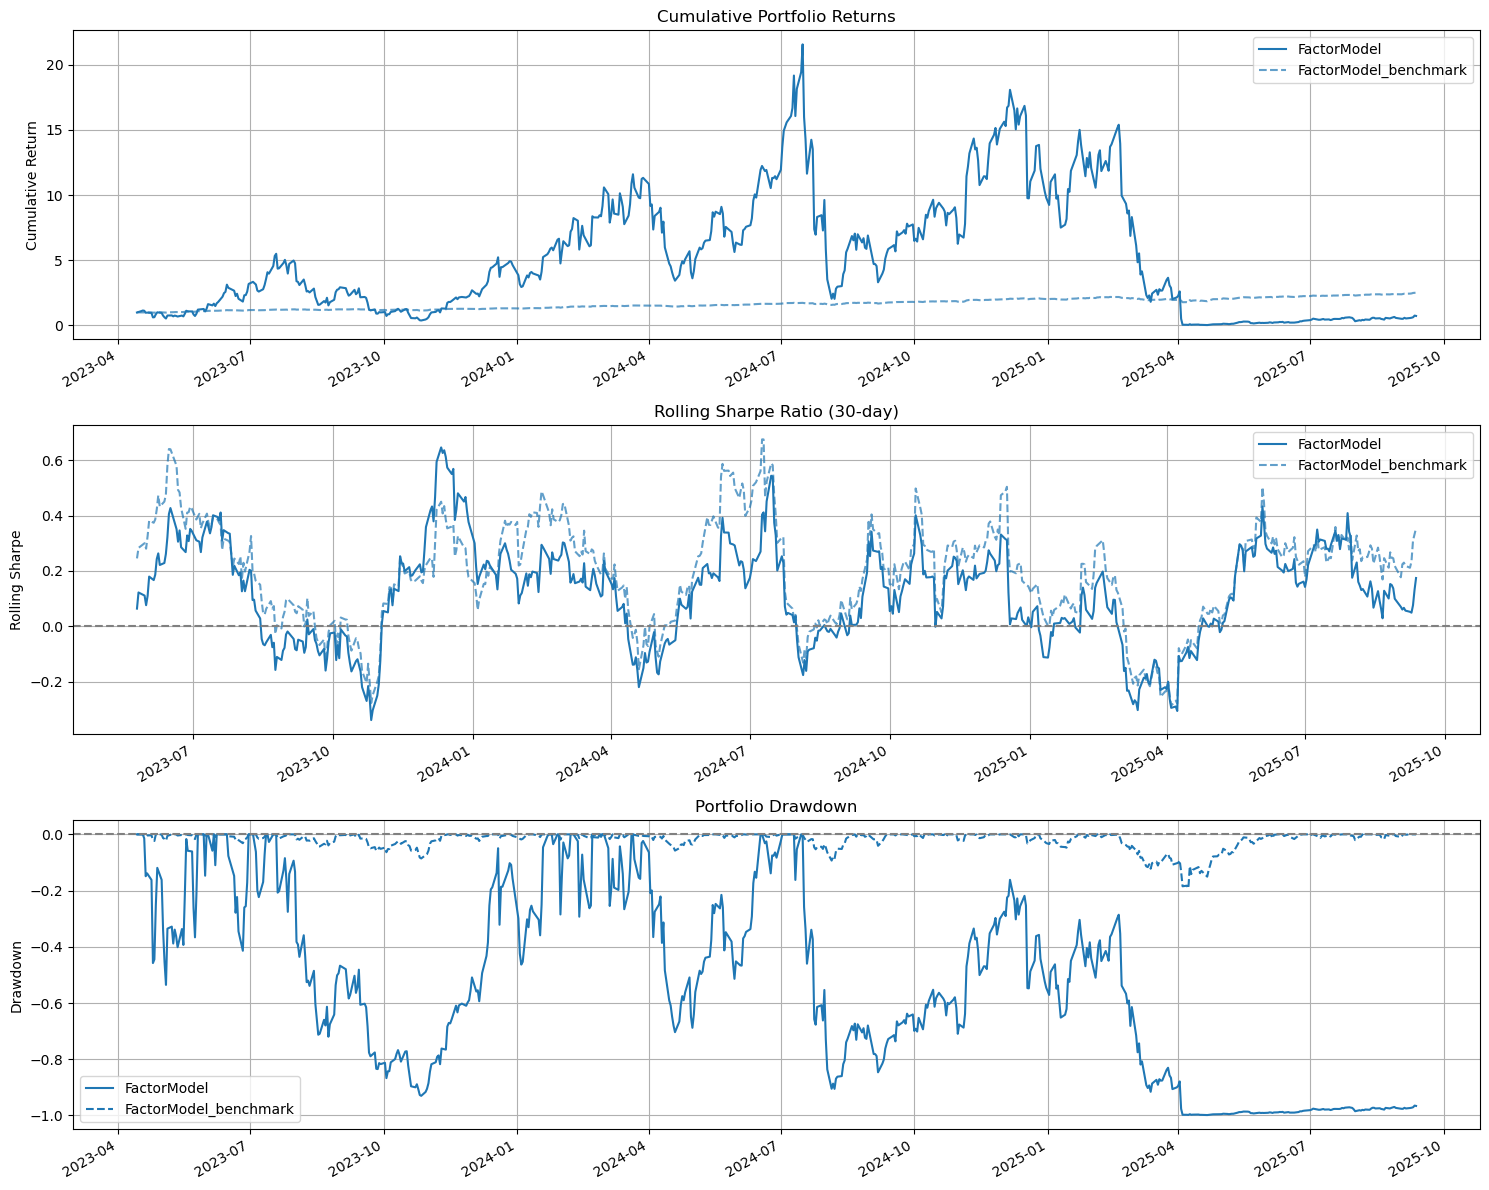

In [10]:
# --- Visualize Results ---
plot_optimizer_performance(results_dict, save_plt=False)

In [11]:
# Generate summary table
summary_df = create_optimizer_summary_table(results_dict)
print("\n--- Performance Summary ---")
display(summary_df.T)


--- Performance Summary ---


,0
Strategy,FactorModel
Portfolio_Annual_Return,3.782935
Portfolio_Annual_Vol,2.609507
Portfolio_Sharpe,1.449674
Portfolio_Max_DD,-3.093092
Benchmark_Annual_Return,0.397804
Benchmark_Annual_Vol,0.170382
Benchmark_Sharpe,2.334774
Benchmark_Max_DD,-0.207299
Excess_Return,3.385131


In [12]:
factor_opt.get_params()

{'budget': 1.0,
 'budgetsht': 0.2,
 'halflife': 10,
 'l': 0.0,
 'method_F': 'hist',
 'method_f': 'ewma1',
 'obj': 'MinRisk',
 'returns_var': 'return',
 'rf': 0.0,
 'rm': 'MV',
 'sht': True,
 'upperlng': 1.0,
 'uppersht': 0.2,
 'use_custom_factor_inputs': False,
 'use_custom_inputs': False,
 'user_input_F': None,
 'user_input_cov': None,
 'user_input_f': None,
 'user_input_mu': None}

In [13]:
factor_opt.get_weights()

AAPL     0.022145
AMZN     0.027153
AVGO     0.007468
BAC      0.050127
BRK.A    0.084504
BRK.B    0.081592
COST     0.034901
GOOG     0.017881
GOOGL    0.017288
HD       0.036659
JNJ      0.059491
JPM      0.061684
LLY      0.010351
MA       0.071007
META     0.017310
MSFT     0.044630
NFLX     0.015092
NVDA     0.021094
ORCL     0.004916
PG       0.101552
PLTR     0.002927
TSLA     0.006404
V        0.055342
WMT      0.027216
XOM      0.121268
Name: weights, dtype: float64

In [14]:
type(results_dict['FactorModel'])

list

In [16]:
fm_results = pd.DataFrame(results_dict['FactorModel'])

In [17]:
fm_results.to_csv("fm_backtest_20250917.csv")

### Wrap-up: Fast, Accessible, and Useful

That’s the entire flow: select a universe, analyze its risk profile with our factor model, and backtest an optimized portfolio against common benchmarks.

This entire process, from data loading to results, can be done in minutes.

**We’re offering free trials of our data and platform. Scan the QR code to learn more.**